# Random Forest

## Importar Dados

In [2]:
import pandas as pd
caminho = '../'

X_test = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv')
y_train = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv')

## RF - Default

In [3]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=100, random_state=14)
random_forest.fit(X_train, y_train)

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===

Acurácia: 0.8288
Precisão: 0.8241
Recall: 0.7722
F1-Score: 0.7895
MCC: 0.5940
AUC: 0.8730
--------------------------------------------------


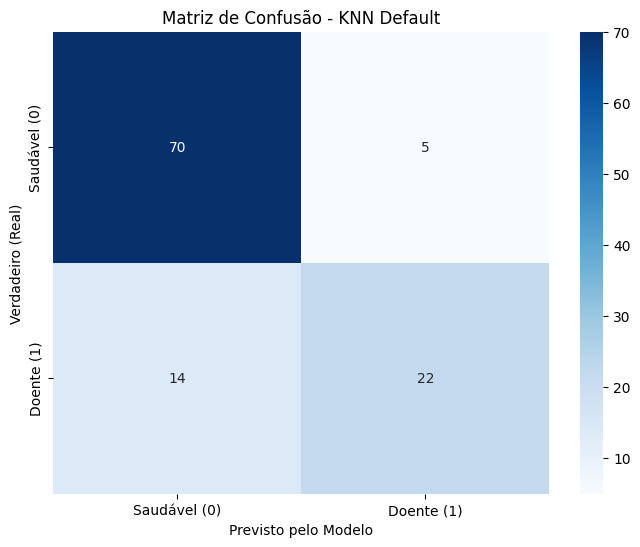

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix)

# Fazendo as Previsões no conjunto de teste
y_pred_def = random_forest.predict(X_test)
y_prob_def = random_forest.predict_proba(X_test)[:, 1]

# Métricas
acuracia_def = accuracy_score(y_test, y_pred_def)
precisao_def = precision_score(y_test, y_pred_def, average='macro', zero_division=0)
recall_def = recall_score(y_test, y_pred_def, average='macro', zero_division=0)
f1_def = f1_score(y_test, y_pred_def, average='macro', zero_division=0)
mcc_def = matthews_corrcoef(y_test, y_pred_def)
auc = roc_auc_score(y_test, y_prob_def)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===\n")
print(f"Acurácia: {acuracia_def:.4f}")
print(f"Precisão: {precisao_def:.4f}")
print(f"Recall: {recall_def:.4f}")
print(f"F1-Score: {f1_def:.4f}")
print(f"MCC: {mcc_def:.4f}")
print(f"AUC: {auc:.4f}")
print("-" * 50)

# Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_def)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])
plt.title('Matriz de Confusão - KNN Default')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## RF - Melhorado

In [6]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    # Hiperparâmetros
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
    }

    clf = RandomForestClassifier(**params, random_state=14)

    score = cross_val_score(clf, X_train, y_train.values.ravel(), scoring='accuracy', n_jobs=-1, cv=5).mean()
    return score

# Criando e executando
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Melhor pontuação: {study.best_value:.4f}")
print("Melhores parâmetros:")
print(study.best_params)

# Treinando o modelo final com os melhores parâmetros encontrados
best_rf = RandomForestClassifier(**study.best_params, random_state=14)
best_rf.fit(X_train, y_train.values.ravel())

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-14 17:15:51,112] A new study created in memory with name: no-name-b3d63e35-0365-4169-b413-edc9bdb44245
Best trial: 0. Best value: 0.810181:   2%|▏         | 1/50 [00:04<04:02,  4.94s/it]

[I 2026-08-14 17:15:56,052] Trial 0 finished with value: 0.8101809954751131 and parameters: {'n_estimators': 133, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 0 with value: 0.8101809954751131.


Best trial: 1. Best value: 0.817873:   4%|▍         | 2/50 [00:08<03:30,  4.38s/it]

[I 2026-08-14 17:16:00,042] Trial 1 finished with value: 0.8178733031674208 and parameters: {'n_estimators': 205, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 1 with value: 0.8178733031674208.


Best trial: 1. Best value: 0.817873:   6%|▌         | 3/50 [00:11<02:43,  3.47s/it]

[I 2026-08-14 17:16:02,436] Trial 2 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 74, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 1 with value: 0.8178733031674208.


Best trial: 1. Best value: 0.817873:   8%|▊         | 4/50 [00:11<01:43,  2.25s/it]

[I 2026-08-14 17:16:02,821] Trial 3 finished with value: 0.7946455505279035 and parameters: {'n_estimators': 193, 'max_depth': 4, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 1 with value: 0.8178733031674208.


Best trial: 1. Best value: 0.817873:  10%|█         | 5/50 [00:12<01:10,  1.57s/it]

[I 2026-08-14 17:16:03,167] Trial 4 finished with value: 0.8062594268476622 and parameters: {'n_estimators': 142, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 1 with value: 0.8178733031674208.


Best trial: 1. Best value: 0.817873:  12%|█▏        | 6/50 [00:12<00:50,  1.16s/it]

[I 2026-08-14 17:16:03,528] Trial 5 finished with value: 0.7829562594268478 and parameters: {'n_estimators': 224, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 1 with value: 0.8178733031674208.


Best trial: 7. Best value: 0.817873:  16%|█▌        | 8/50 [00:12<00:26,  1.57it/s]

[I 2026-08-14 17:16:03,826] Trial 6 finished with value: 0.7984917043740574 and parameters: {'n_estimators': 188, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 1 with value: 0.8178733031674208.
[I 2026-08-14 17:16:03,949] Trial 7 finished with value: 0.8178733031674209 and parameters: {'n_estimators': 64, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 7 with value: 0.8178733031674209.


Best trial: 7. Best value: 0.817873:  20%|██        | 10/50 [00:13<00:16,  2.44it/s]

[I 2026-08-14 17:16:04,258] Trial 8 finished with value: 0.7984917043740574 and parameters: {'n_estimators': 207, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 7 with value: 0.8178733031674209.
[I 2026-08-14 17:16:04,390] Trial 9 finished with value: 0.8063348416289593 and parameters: {'n_estimators': 76, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 7 with value: 0.8178733031674209.


Best trial: 7. Best value: 0.817873:  22%|██▏       | 11/50 [00:13<00:16,  2.35it/s]

[I 2026-08-14 17:16:04,849] Trial 10 finished with value: 0.7947963800904978 and parameters: {'n_estimators': 294, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 7 with value: 0.8178733031674209.


Best trial: 11. Best value: 0.817949:  24%|██▍       | 12/50 [00:14<00:16,  2.26it/s]

[I 2026-08-14 17:16:05,326] Trial 11 finished with value: 0.8179487179487179 and parameters: {'n_estimators': 259, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  26%|██▌       | 13/50 [00:14<00:18,  1.99it/s]

[I 2026-08-14 17:16:05,972] Trial 12 finished with value: 0.8179487179487179 and parameters: {'n_estimators': 283, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  28%|██▊       | 14/50 [00:15<00:18,  1.92it/s]

[I 2026-08-14 17:16:06,536] Trial 13 finished with value: 0.8062594268476622 and parameters: {'n_estimators': 292, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  30%|███       | 15/50 [00:15<00:18,  1.87it/s]

[I 2026-08-14 17:16:07,096] Trial 14 finished with value: 0.8024132730015083 and parameters: {'n_estimators': 256, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  32%|███▏      | 16/50 [00:16<00:17,  1.98it/s]

[I 2026-08-14 17:16:07,540] Trial 15 finished with value: 0.8062594268476622 and parameters: {'n_estimators': 253, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  34%|███▍      | 17/50 [00:16<00:17,  1.94it/s]

[I 2026-08-14 17:16:08,083] Trial 16 finished with value: 0.8141025641025641 and parameters: {'n_estimators': 259, 'max_depth': 13, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  36%|███▌      | 18/50 [00:17<00:15,  2.02it/s]

[I 2026-08-14 17:16:08,523] Trial 17 finished with value: 0.7945701357466064 and parameters: {'n_estimators': 238, 'max_depth': 12, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  38%|███▊      | 19/50 [00:17<00:15,  1.98it/s]

[I 2026-08-14 17:16:09,055] Trial 18 finished with value: 0.7985671191553545 and parameters: {'n_estimators': 281, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  40%|████      | 20/50 [00:18<00:13,  2.23it/s]

[I 2026-08-14 17:16:09,373] Trial 19 finished with value: 0.8064102564102564 and parameters: {'n_estimators': 156, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  42%|████▏     | 21/50 [00:18<00:13,  2.16it/s]

[I 2026-08-14 17:16:09,867] Trial 20 finished with value: 0.8101809954751131 and parameters: {'n_estimators': 268, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  44%|████▍     | 22/50 [00:18<00:10,  2.61it/s]

[I 2026-08-14 17:16:10,065] Trial 21 finished with value: 0.7985671191553545 and parameters: {'n_estimators': 113, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  46%|████▌     | 23/50 [00:19<00:08,  3.05it/s]

[I 2026-08-14 17:16:10,266] Trial 22 finished with value: 0.8101809954751131 and parameters: {'n_estimators': 103, 'max_depth': 12, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  50%|█████     | 25/50 [00:19<00:06,  3.67it/s]

[I 2026-08-14 17:16:10,628] Trial 23 finished with value: 0.8102564102564103 and parameters: {'n_estimators': 174, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 11 with value: 0.8179487179487179.
[I 2026-08-14 17:16:10,744] Trial 24 finished with value: 0.7985671191553545 and parameters: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  52%|█████▏    | 26/50 [00:20<00:07,  3.20it/s]

[I 2026-08-14 17:16:11,154] Trial 25 finished with value: 0.814027149321267 and parameters: {'n_estimators': 234, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 11. Best value: 0.817949:  54%|█████▍    | 27/50 [00:20<00:08,  2.62it/s]

[I 2026-08-14 17:16:11,697] Trial 26 finished with value: 0.7830316742081447 and parameters: {'n_estimators': 277, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 11 with value: 0.8179487179487179.


Best trial: 27. Best value: 0.821795:  56%|█████▌    | 28/50 [00:20<00:08,  2.61it/s]

[I 2026-08-14 17:16:12,085] Trial 27 finished with value: 0.8217948717948718 and parameters: {'n_estimators': 169, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  58%|█████▊    | 29/50 [00:21<00:07,  2.77it/s]

[I 2026-08-14 17:16:12,389] Trial 28 finished with value: 0.8179487179487179 and parameters: {'n_estimators': 167, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  60%|██████    | 30/50 [00:21<00:06,  2.98it/s]

[I 2026-08-14 17:16:12,666] Trial 29 finished with value: 0.8178733031674208 and parameters: {'n_estimators': 122, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  62%|██████▏   | 31/50 [00:21<00:06,  2.72it/s]

[I 2026-08-14 17:16:13,108] Trial 30 finished with value: 0.8179487179487179 and parameters: {'n_estimators': 219, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  64%|██████▍   | 32/50 [00:22<00:06,  2.81it/s]

[I 2026-08-14 17:16:13,437] Trial 31 finished with value: 0.814027149321267 and parameters: {'n_estimators': 161, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  66%|██████▌   | 33/50 [00:22<00:05,  2.98it/s]

[I 2026-08-14 17:16:13,726] Trial 32 finished with value: 0.8101809954751131 and parameters: {'n_estimators': 143, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  68%|██████▊   | 34/50 [00:22<00:05,  2.98it/s]

[I 2026-08-14 17:16:14,063] Trial 33 finished with value: 0.8179487179487179 and parameters: {'n_estimators': 178, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  70%|███████   | 35/50 [00:23<00:05,  2.81it/s]

[I 2026-08-14 17:16:14,463] Trial 34 finished with value: 0.7985671191553545 and parameters: {'n_estimators': 202, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  72%|███████▏  | 36/50 [00:23<00:05,  2.41it/s]

[I 2026-08-14 17:16:15,020] Trial 35 finished with value: 0.8141025641025641 and parameters: {'n_estimators': 300, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  74%|███████▍  | 37/50 [00:24<00:05,  2.59it/s]

[I 2026-08-14 17:16:15,335] Trial 36 finished with value: 0.8178733031674208 and parameters: {'n_estimators': 154, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  76%|███████▌  | 38/50 [00:24<00:04,  2.67it/s]

[I 2026-08-14 17:16:15,685] Trial 37 finished with value: 0.814027149321267 and parameters: {'n_estimators': 168, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  78%|███████▊  | 39/50 [00:24<00:04,  2.64it/s]

[I 2026-08-14 17:16:16,073] Trial 38 finished with value: 0.8023378582202112 and parameters: {'n_estimators': 190, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  80%|████████  | 40/50 [00:25<00:04,  2.42it/s]

[I 2026-08-14 17:16:16,568] Trial 39 finished with value: 0.7945701357466064 and parameters: {'n_estimators': 245, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  82%|████████▏ | 41/50 [00:26<00:04,  2.17it/s]

[I 2026-08-14 17:16:17,138] Trial 40 finished with value: 0.806184012066365 and parameters: {'n_estimators': 220, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  84%|████████▍ | 42/50 [00:26<00:03,  2.20it/s]

[I 2026-08-14 17:16:17,576] Trial 41 finished with value: 0.8179487179487179 and parameters: {'n_estimators': 223, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  86%|████████▌ | 43/50 [00:26<00:03,  2.14it/s]

[I 2026-08-14 17:16:18,076] Trial 42 finished with value: 0.814027149321267 and parameters: {'n_estimators': 207, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  88%|████████▊ | 44/50 [00:27<00:02,  2.05it/s]

[I 2026-08-14 17:16:18,609] Trial 43 finished with value: 0.8141025641025641 and parameters: {'n_estimators': 278, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  90%|█████████ | 45/50 [00:27<00:02,  2.33it/s]

[I 2026-08-14 17:16:18,906] Trial 44 finished with value: 0.810105580693816 and parameters: {'n_estimators': 139, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  92%|█████████▏| 46/50 [00:28<00:01,  2.34it/s]

[I 2026-08-14 17:16:19,326] Trial 45 finished with value: 0.8179487179487179 and parameters: {'n_estimators': 214, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  94%|█████████▍| 47/50 [00:28<00:01,  2.50it/s]

[I 2026-08-14 17:16:19,665] Trial 46 finished with value: 0.8138763197586727 and parameters: {'n_estimators': 188, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  96%|█████████▌| 48/50 [00:28<00:00,  2.45it/s]

[I 2026-08-14 17:16:20,093] Trial 47 finished with value: 0.7946455505279035 and parameters: {'n_estimators': 239, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795:  98%|█████████▊| 49/50 [00:29<00:00,  2.37it/s]

[I 2026-08-14 17:16:20,546] Trial 48 finished with value: 0.8179487179487179 and parameters: {'n_estimators': 264, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.


Best trial: 27. Best value: 0.821795: 100%|██████████| 50/50 [00:29<00:00,  1.67it/s]

[I 2026-08-14 17:16:21,029] Trial 49 finished with value: 0.8063348416289593 and parameters: {'n_estimators': 287, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 27 with value: 0.8217948717948718.
Melhor pontuação: 0.8218
Melhores parâmetros:
{'n_estimators': 169, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}


,n_estimators,169
,criterion,'entropy'
,max_depth,9
,min_samples_split,8
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig = optuna.visualization.plot_optimization_history(study)
fig.show()

=== MÉTRICAS DE DESEMPENHO ===

Acurácia: 0.8018
Precisão: 0.7905
Recall:   0.7378
F1-Score: 0.7538
MCC:      0.5256
AUC:      0.8715
--------------------------------------------------


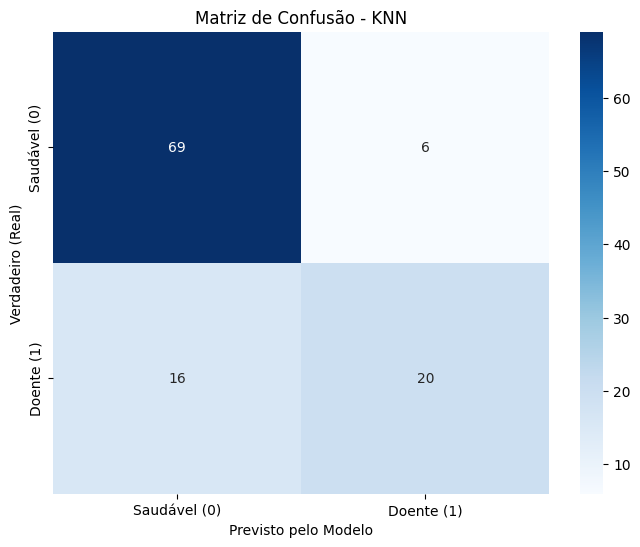

In [8]:
# Fazendo as Previsões
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

# Métricas
acuracia_best = accuracy_score(y_test, y_pred_best)
precisao_best = precision_score(y_test, y_pred_best, average='macro')
recall_best   = recall_score(y_test, y_pred_best, average='macro')
f1_best       = f1_score(y_test, y_pred_best, average='macro')
mcc_best      = matthews_corrcoef(y_test, y_pred_best)

# O AUC binário recebe as classes reais e as probabilidades diretamente
auc = roc_auc_score(y_test, y_prob_best)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO ===\n")
print(f"Acurácia: {acuracia_best:.4f}")
print(f"Precisão: {precisao_best:.4f}")
print(f"Recall:   {recall_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")
print(f"MCC:      {mcc_best:.4f}")
print(f"AUC:      {auc:.4f}")
print("-" * 50)


# 5. Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)

# Labels ajustados exclusivamente para as duas doenças
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])

plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## Salvar Resultados

In [9]:
import os
import pandas as pd

nome_modelo = 'rf'

# Caminhos dos arquivos
pasta_results = os.path.join(caminho, 'results')
os.makedirs(pasta_results, exist_ok=True)

arquivo_pred = os.path.join(pasta_results, 'predicoes.csv')
arquivo_proba = os.path.join(pasta_results, 'probabilidades.csv')

# Monta a linha com as predições de teste
linha_pred_teste = [nome_modelo, 'teste'] + list(y_pred_best)

# Salva adicionando no final do arquivo (mode='a')
pd.DataFrame([linha_pred_teste]).to_csv(
    arquivo_pred, mode='a', header=False, index=False
)

# Monta a linha com as probabilidades de teste 
probs = (
    y_prob_best[:, 1]
    if hasattr(y_prob_best, 'ndim') and y_prob_best.ndim == 2
    else y_prob_best
)
linha_proba_teste = [nome_modelo, 'teste'] + list(probs)

pd.DataFrame([linha_proba_teste]).to_csv(
    arquivo_proba, mode='a', header=False, index=False
)

print(f'Predições e probabilidades do modelo {nome_modelo} salvas com sucesso!')

Predições e probabilidades do modelo rf salvas com sucesso!
